# 1 TLS + Cavity Delayed-Waveguide Example

This example runs the non-Markovian atom-cavity-waveguide simulation in one function: parameter input, time evolution, expectation values, and plotting.

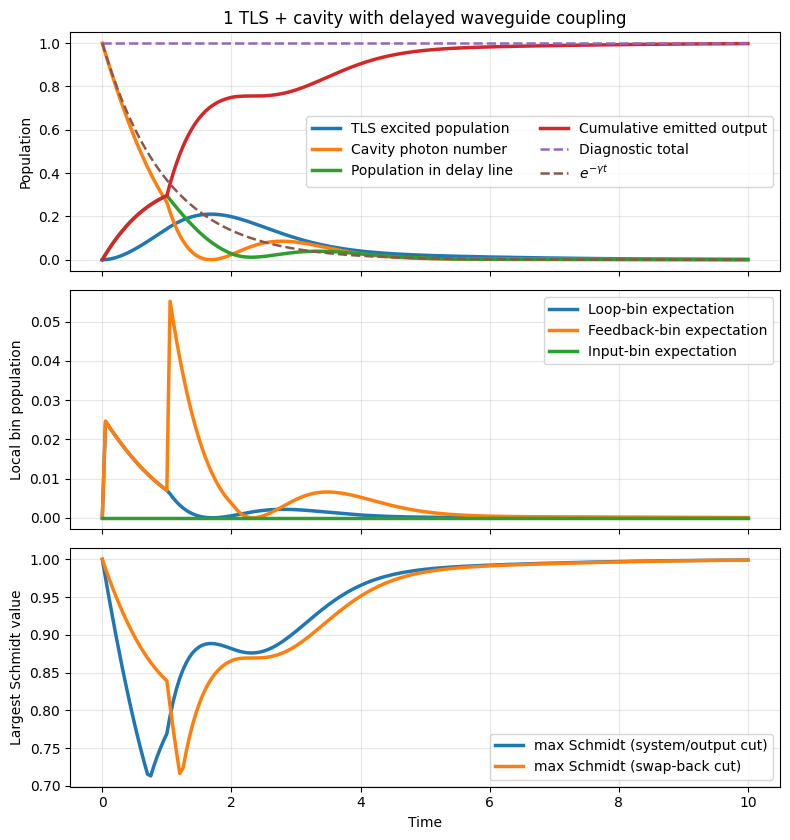

In [3]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import time as t
import wqedmps as qmps


def tls_cavity_product_state(
    d_cavity: int,
    tls_excited: bool = True,
    cavity_n: int = 0,
) -> np.ndarray:
    """Build a local product tensor |TLS> ⊗ |n_cavity>."""
    if cavity_n < 0 or cavity_n >= d_cavity:
        raise ValueError("cavity_n must satisfy 0 <= cavity_n < d_cavity")

    tls_vec = (
        np.array([0.0, 1.0], dtype=complex)
        if tls_excited
        else np.array([1.0, 0.0], dtype=complex)
    )
    cavity_vec = np.zeros(d_cavity, dtype=complex)
    cavity_vec[cavity_n] = 1.0
    return np.kron(tls_vec, cavity_vec).reshape(1, 2 * d_cavity, 1)


def _delay_window_total(per_bin: np.ndarray, delay_steps: int) -> np.ndarray:
    """Accumulate the population currently stored over one delay window."""
    values = np.asarray(per_bin, dtype=float)
    if delay_steps <= 0:
        return np.zeros_like(values)

    csum = np.cumsum(values)
    total = csum.copy()
    if len(values) > delay_steps:
        total[delay_steps:] = csum[delay_steps:] - csum[:-delay_steps]
    return total


def run_tls_cavity_feedback_example() -> tuple[
    qmps.InputParams, qmps.Bins, dict[str, np.ndarray | float]
]:
    """Run the TLS-cavity delayed-waveguide example end-to-end."""
    # 1. Define physical and numerical parameters.
    params = qmps.InputParams(
        delta_t=0.05,
        tmax=10.0,
        tau=1,
        d_sys_total=np.array([2, 4]),
        d_t_total=np.array([3]),
        gamma_l=0.5,
        gamma_r=0.5,
        g=0.5,
        phase=0,
        bond_max=18,
        atol=1e-12,
    )

    d_cavity = int(params.d_sys_total[1])

    # 2. Build the initial system-field state and local Hamiltonian.
    initial_system = tls_cavity_product_state(
        d_cavity=d_cavity, tls_excited=False, cavity_n=1
    )
    initial_field = qmps.vacuum(params.tmax, params)
    start_time = t.time()
    hamiltonian = qmps.hamiltonian_1tls_cavity_nmar(
        params,
        delta_atom=0.0,
        delta_cavity=0.0,
    )

    # 3. Run the delayed time evolution.
    bins = qmps.t_evol_nmar_seemps(
        hamiltonian,
        initial_system,
        initial_field,
        params,
    )

    # 4. Compute system and field observables.
    times = np.asarray(bins.times, dtype=float)
    tls_pop_op = np.kron(qmps.tls_pop(2), np.eye(d_cavity, dtype=complex))
    cavity_num_op = np.kron(np.eye(2, dtype=complex), qmps.num_op(d_cavity))

    tls_pop = np.asarray(
        qmps.single_time_expectation(bins.system_states, tls_pop_op),
        dtype=float,
    )
    cavity_pop = np.asarray(
        qmps.single_time_expectation(bins.system_states, cavity_num_op),
        dtype=float,
    )
    loop_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.loop_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )
    feedback_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.output_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )
    input_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.input_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )

    delay_total_pop = _delay_window_total(loop_bin_pop, params.delay_steps)
    emitted_output = np.cumsum(feedback_bin_pop)
    total_excitation = tls_pop + cavity_pop + delay_total_pop + emitted_output

    schmidt_max = np.array(
        [
            np.max(np.asarray(s, dtype=float)) if len(s) > 0 else 0.0
            for s in bins.schmidt
        ],
        dtype=float,
    )
    schmidt_tau_max = np.array(
        [
            np.max(np.asarray(s, dtype=float)) if len(s) > 0 else 0.0
            for s in bins.schmidt_tau
        ],
        dtype=float,
    )

    runtime = float(t.time() - start_time)
    observables = {
        "times": times,
        "tls_pop": tls_pop,
        "cavity_pop": cavity_pop,
        "loop_bin_pop": loop_bin_pop,
        "feedback_bin_pop": feedback_bin_pop,
        "input_bin_pop": input_bin_pop,
        "delay_total_pop": delay_total_pop,
        "emitted_output": emitted_output,
        "total_excitation": total_excitation,
        "schmidt_max": schmidt_max,
        "schmidt_tau_max": schmidt_tau_max,
        "runtime": runtime,
        "max_abs_error": float(np.max(np.abs(total_excitation - total_excitation[0]))),
    }

    # 5. Plot atom-cavity populations, field populations and Schmidt diagnostics.
    fig, axes = plt.subplots(3, 1, figsize=(8.0, 8.5), sharex=True)

    axes[0].plot(times, tls_pop, lw=2.5, label="TLS excited population")
    axes[0].plot(times, cavity_pop, lw=2.5, label="Cavity photon number")
    axes[0].plot(times, delay_total_pop, lw=2.5, label="Population in delay line")
    axes[0].plot(times, emitted_output, lw=2.5, label="Cumulative emitted output")
    axes[0].plot(times, total_excitation, "--", lw=1.8, label="Diagnostic total")
    gamma_total = 1
    axes[0].plot(
        times, np.exp(-gamma_total * times), "--", lw=1.8, label=rf"$e^{{-\gamma t}}$"
    )
    axes[0].set_ylabel("Population")
    axes[0].set_title("1 TLS + cavity with delayed waveguide coupling")
    axes[0].legend(ncol=2)
    axes[0].grid(alpha=0.3)

    axes[1].plot(times, loop_bin_pop, lw=2.5, label="Loop-bin expectation")
    axes[1].plot(times, feedback_bin_pop, lw=2.5, label="Feedback-bin expectation")
    axes[1].plot(times, input_bin_pop, lw=2.5, label="Input-bin expectation")
    axes[1].set_ylabel("Local bin population")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(times, schmidt_max, lw=2.5, label="max Schmidt (system/output cut)")
    axes[2].plot(times, schmidt_tau_max, lw=2.5, label="max Schmidt (swap-back cut)")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Largest Schmidt value")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return params, bins, observables


params, bins, observables = run_tls_cavity_feedback_example()
